# MLP Policy — Multi-Env Training
Train the MLP policy on any checker. Checkpoints saved to `./checkpoints_{checker_name}_n{N}/`.

In [1]:
import sys, os
sys.path.insert(0, os.path.dirname(os.path.abspath('.')))

import torch
import numpy as np

import matplotlib.pyplot as plt

from turan_env_c import (
    CEnv,
    CHECKER_C3, CHECKER_C4, CHECKER_C3C4,
    CHECKER_K23, CHECKER_THETA123, CHECKER_BULL,
    CHECKER_BOWTIE, CHECKER_K4,
)
from policy import MLPActorCritic
from ppo3 import CFG, train, load_checkpoint, run_episodes

print(f"torch {torch.__version__}  cuda={torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"  {torch.cuda.get_device_name(0)}")

/root/backtoRL/.venv/lib/python3.12/site-packages/torch/cuda/__init__.py:65: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


torch 2.10.0+cu130  cuda=True
  NVIDIA GeForce RTX 5090


## Pick your setup
Edit the two cells below, then run all.

In [ ]:
# ── CHANGE THESE ──────────────────────────────────────────────────────────────
CHECKER     = CHECKER_C3   # CHECKER_C3 | CHECKER_C4 | CHECKER_K4 | ...
N           = 100        # graph size
RESUME      = False     # e.g. './checkpoints_c3_n20/best.pt'
TRAIN       = True  # set False to skip training and load RESUME for eval only
# ──────────────────────────────────────────────────────────────────────────────

CHECKER_NAMES = {
    CHECKER_C3:       'c3',
    CHECKER_C4:       'c4',
    CHECKER_C3C4:     'c3c4',
    CHECKER_K23:      'k23',
    CHECKER_THETA123: 'theta123',
    CHECKER_BULL:     'bull',
    CHECKER_BOWTIE:   'bowtie',
    CHECKER_K4:       'k4',
}

# Known Turán-style upper bounds (best known extremal values)
# C3:  Mantel's theorem  ex(n, C3)  = floor(n²/4)
# C4:  Reiman / Bondy–Simonovits, roughly ½·n^{3/2}
# K4:  Turán T(n,3):  (1 - 1/3)·n²/2 ≈ n²/3
KNOWN_BOUNDS = {
    CHECKER_C3:  N**2 // 4,
    CHECKER_C4:  None,     # no simple closed form at small n
    CHECKER_K4:  N**2 // 3,
}

checker_name = CHECKER_NAMES[CHECKER]
ckpt_dir     = f'./checkpoints_{checker_name}_n{N}'
bound        = KNOWN_BOUNDS.get(CHECKER)

print(f"Checker : {checker_name}  (id={CHECKER})")
print(f"N       : {N}")
print(f"Bound   : {bound if bound else 'unknown'}")
print(f"Ckpt dir: {ckpt_dir}")
print(f"Train   : {TRAIN}  |  Resume: {RESUME}")

Checker : c3  (id=0)
N       : 20
Bound   : 100
Ckpt dir: ./checkpoints_c3_n20
Train   : False  |  Resume: ./checkpoints_c3_n20/final.pt


In [75]:
cfg = {**CFG}   # copy defaults

cfg['n']              = N
cfg['checker_id']     = CHECKER
cfg['checkpoint_dir'] = ckpt_dir

# ── hyperparams (edit freely, these override the checkpoint when resuming) ──
cfg['total_steps']  = 60_000_000   # INCREASE THIS to continue training on resume
cfg['lr']         = 1e-6
cfg['ent_coef']   = 0.05
cfg['num_envs']   = 1024

for k, v in cfg.items():
    print(f"  {k:20s} = {v}")


  n                    = 20
  num_envs             = 1024
  checker_id           = 0
  n_steps              = 64
  n_epochs             = 10
  batch_size           = 2048
  lr                   = 1e-06
  gamma                = 0.99
  gae_lambda           = 0.95
  clip_eps             = 0.2
  vf_coef              = 0.5
  ent_coef             = 0.05
  max_grad_norm        = 0.5
  total_steps          = 60000000
  device               = cuda
  log_interval         = 10
  save_interval        = 100
  checkpoint_dir       = ./checkpoints_c3_n20


## Env sanity + benchmark

In [76]:
env = CEnv(n=N, num_envs=cfg['num_envs'], checker_id=CHECKER)
obs = env.reset()
print(f"obs shape : {obs.shape}   dtype: {obs.dtype}")
print(f"num_actions: {env.num_actions}  (= {N}*{N-1}/2)")
env.benchmark(steps=200)
env.close()

obs shape : (1024, 190)   dtype: bool
num_actions: 190  (= 20*19/2)
200 steps x 1024 envs in 0.01s
  22,001,779 steps/sec
  22.00M steps/sec


## Train

In [77]:
if TRAIN:
    policy, history = train(cfg=cfg, resume=RESUME)
else:
    assert RESUME and os.path.exists(RESUME), f"Set RESUME to a valid checkpoint path when TRAIN=False (got: {RESUME})"
    policy, _, cfg, _, _, _ = load_checkpoint(RESUME)
    policy.eval()
    history = []
    print(f"Loaded checkpoint: {RESUME} (training skipped)")

loaded ./checkpoints_c3_n20/final.pt  iter=915  steps=59,965,440  best=81.93
Loaded checkpoint: ./checkpoints_c3_n20/final.pt (training skipped)


## Training curves

ValueError: v cannot be empty

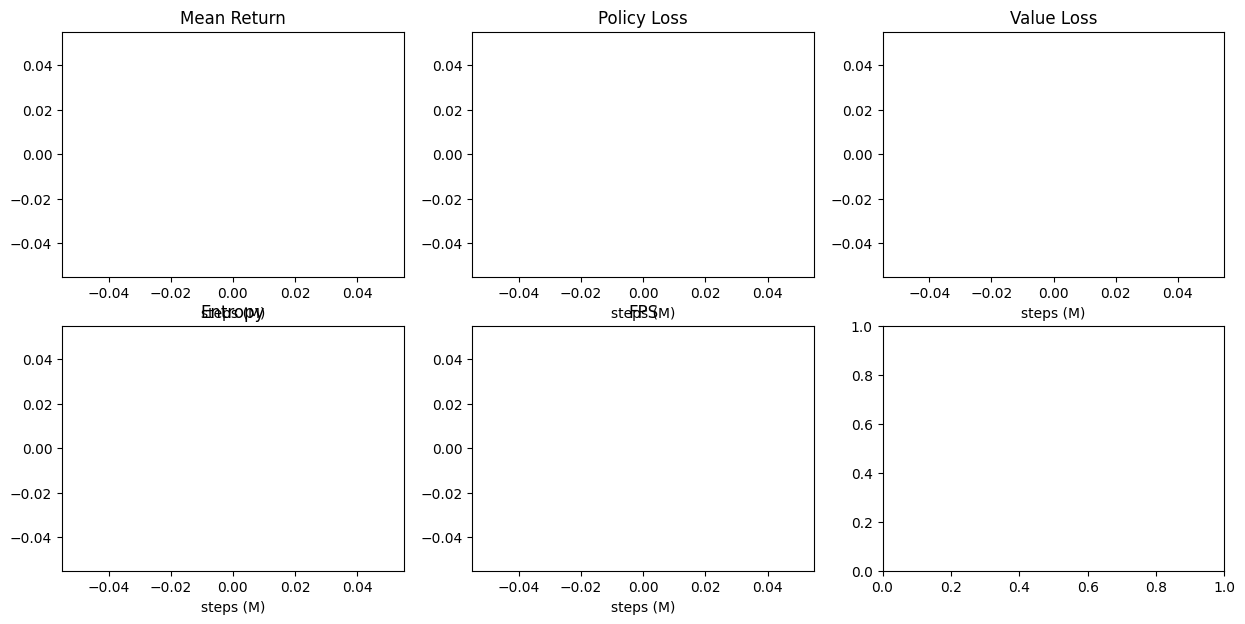

In [78]:
steps  = [h['global_step'] / 1e6 for h in history]
rets   = [h['mean_ret']    for h in history]
pg     = [h['pg']          for h in history]
vf     = [h['vf']          for h in history]
ent    = [h['ent']         for h in history]
fps_h  = [h['fps']         for h in history]

fig, axes = plt.subplots(2, 3, figsize=(15, 7))

axes[0,0].plot(steps, rets);  axes[0,0].set_title('Mean Return');    axes[0,0].set_xlabel('steps (M)')
axes[0,1].plot(steps, pg);    axes[0,1].set_title('Policy Loss');    axes[0,1].set_xlabel('steps (M)')
axes[0,2].plot(steps, vf);    axes[0,2].set_title('Value Loss');     axes[0,2].set_xlabel('steps (M)')
axes[1,0].plot(steps, ent);   axes[1,0].set_title('Entropy');        axes[1,0].set_xlabel('steps (M)')
axes[1,1].plot(steps, fps_h); axes[1,1].set_title('FPS');            axes[1,1].set_xlabel('steps (M)')

# smoothed return + Turán bound line
window = max(1, len(rets) // 20)
smooth = np.convolve(rets, np.ones(window)/window, mode='valid')
axes[1,2].plot(steps[window-1:], smooth, label=f'smoothed (w={window})')
axes[1,2].plot(steps, rets, alpha=0.3, label='raw')
if bound:
    axes[1,2].axhline(bound, color='red', linestyle='--', label=f'bound={bound}')
axes[1,2].set_title('Return (smoothed)'); axes[1,2].set_xlabel('steps (M)'); axes[1,2].legend()

best_ret = max(h['mean_ret'] for h in history)
plt.suptitle(f'MLP — {checker_name.upper()}  n={N}  best={best_ret:.2f}' +
             (f'  bound={bound}  ({best_ret/bound*100:.1f}%)' if bound else ''),
             fontsize=12)
plt.tight_layout()
plt.show()

## Evaluate — draw the densest graph found

Edge counts : [81, 81, 81, 81, 81, 81, 81, 81, 81, 81, 81, 81, 81, 81, 81, 81]
Best found  : 81  (81.0% of bound=100)


/tmp/ipykernel_4414/3785776145.py:20: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


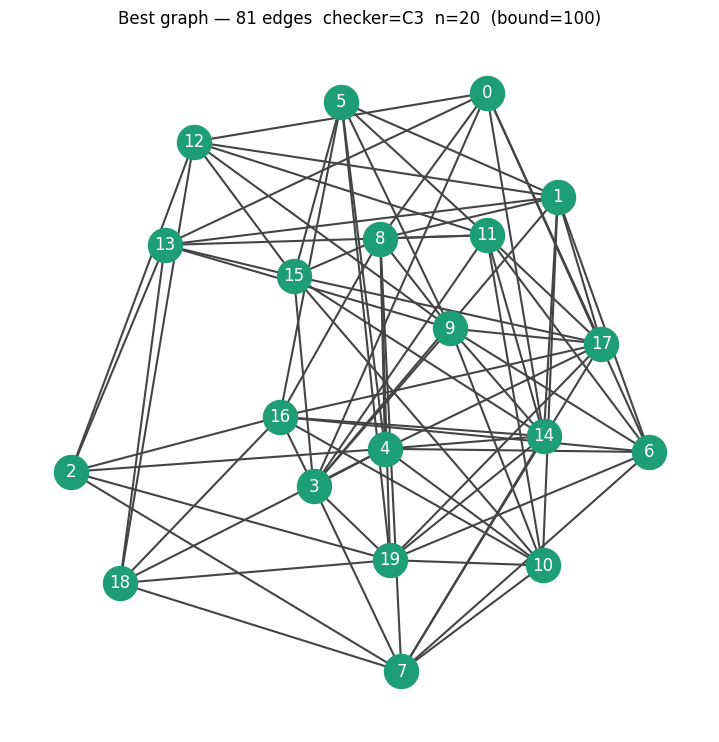

In [79]:
import networkx as nx

policy.eval()
adjs = run_episodes(policy, cfg, n_episodes=16, deterministic=True)

edge_counts = [int(adj.sum()) // 2 for adj in adjs]
print(f"Edge counts : {sorted(edge_counts, reverse=True)}")
print(f"Best found  : {max(edge_counts)}" + (f"  ({max(edge_counts)/bound*100:.1f}% of bound={bound})" if bound else ''))

best_adj = adjs[np.argmax(edge_counts)]
G   = nx.from_numpy_array(best_adj)
pos = nx.spring_layout(G, seed=42)

plt.figure(figsize=(7, 7))
nx.draw(G, pos, with_labels=True,
        node_color='#1D9E75', node_size=600,
        font_color='white', edge_color='#444', width=1.5)
plt.title(f"Best graph — {max(edge_counts)} edges  checker={checker_name.upper()}  n={N}" +
          (f'  (bound={bound})' if bound else ''))
plt.tight_layout()

plt.show()